- 항공편 지연 예측
    - 특정 조건(계절, 거리, 항공사)에서 비행기가 지연될 것인가


- 사용 데이터 (Features)
    - MONTH
    - DAY_OF_WEEK
    - HOUR
    - DISTANCE
    - AIRLINE

- 데이터
    - https://www.kaggle.com/datasets/usdot/flight-delays/data?select=airlines.csv

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score

# 폰트 및 마이너스 깨짐 설정
plt.rcParams['font.family'] = 'Malgun Gothic'   # 맑은 고딕
plt.rcParams['axes.unicode_minus'] = False      # 마이너스(-) 깨짐 방지


In [3]:
# 전체 데이터 읽어오기
df = pd.read_csv('./data/flights.csv')
df = df.sample(n=5000, random_state=42)
df.tail()

C:\Users\user\AppData\Local\Temp\ipykernel_14064\2464579170.py:2: DtypeWarning: Columns (7,8) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('./data/flights.csv')


,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,...,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
2501394,2015,6,7,7,EV,4995,N857AS,ATL,SHV,2305,...,2352.0,5.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
1212176,2015,3,20,5,DL,1154,N989DL,ATL,BOS,902,...,1143.0,8.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
3320074,2015,7,26,7,WN,43,N520SW,HOU,HRL,1845,...,1931.0,-9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
1991163,2015,5,7,4,B6,315,N190JB,SYR,JFK,1116,...,1211.0,-17.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
1734554,2015,4,21,2,DL,1489,N970AT,ATL,IAH,1349,...,1505.0,-1.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN


| column |  | description |
| ---- | ---- | ---- |
|MONTH|월|1~12월, 계절별 지연 차이 확인 가능|
|DAY_OF_WEEK|요일|1~7, 월요일 ~ 일요일|
|AIRLINE|항공사 코드| |
|ORIGIN_AIRPORT|출발 공항 코드||
|DESTINATION_AIRPORT|도착 공항 코드||
|SCHEDULED_DEPARTURE|시간대별 혼잡도||
|DISTANCE|비행 거리 ||
|DEPARTURE_DELAY|출발 지연 시간|- : 조기 출발|
| ---- | ---- | ---- |
|DELAYED|지연 여부|지연 : 1, 정상 : 0|
|HOUR|시간대|0시 ~ 23시|

In [4]:
# 사용할 컬럼만 뽑아내서 새로운 데이터프레임 만들기
flight = [
    'MONTH',
    'DAY_OF_WEEK',
    'AIRLINE',
    'ORIGIN_AIRPORT',
    'DESTINATION_AIRPORT',
    'SCHEDULED_DEPARTURE',
    'DISTANCE',
    'DEPARTURE_DELAY'
]

flight = df[flight]
flight

,MONTH,DAY_OF_WEEK,AIRLINE,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,DISTANCE,DEPARTURE_DELAY
1508570,4,2,EV,FWA,DTW,1340,128,-5.0
363270,1,6,AS,LAS,SEA,1910,867,-12.0
3003945,7,3,WN,OAK,SEA,630,672,-4.0
2291425,5,2,WN,STL,DAL,810,546,153.0
2973084,7,1,UA,IAH,HNL,1000,3904,8.0
...,...,...,...,...,...,...,...,...
2501394,6,7,EV,ATL,SHV,2305,551,4.0
1212176,3,5,DL,ATL,BOS,902,946,9.0
3320074,7,7,WN,HOU,HRL,1845,277,-2.0
1991163,5,4,B6,SYR,JFK,1116,209,-3.0


In [ ]:
flight.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5000 entries, 1508570 to 1734554
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   MONTH                5000 non-null   int64  
 1   DAY_OF_WEEK          5000 non-null   int64  
 2   AIRLINE              5000 non-null   object 
 3   ORIGIN_AIRPORT       5000 non-null   object 
 4   DESTINATION_AIRPORT  5000 non-null   object 
 5   SCHEDULED_DEPARTURE  5000 non-null   int64  
 6   DISTANCE             5000 non-null   int64  
 7   DEPARTURE_DELAY      4941 non-null   float64
dtypes: float64(1), int64(4), object(3)
memory usage: 351.6+ KB


In [ ]:
flight.describe()

,MONTH,DAY_OF_WEEK,SCHEDULED_DEPARTURE,DISTANCE,DEPARTURE_DELAY
count,5000.000000,5000.000000,5000.000000,5000.000000,4941.000000
mean,6.515800,3.889800,1332.538200,831.194200,9.843554
std,3.439028,1.995207,481.280695,616.820952,34.372625
min,1.000000,1.000000,15.000000,67.000000,-36.000000
25%,4.000000,2.000000,925.000000,371.000000,-5.000000
50%,7.000000,4.000000,1323.000000,651.000000,-1.000000
75%,10.000000,6.000000,1735.000000,1076.000000,8.000000
max,12.000000,7.000000,2359.000000,4983.000000,588.000000


In [ ]:
flight.isnull().sum()

MONTH                   0
DAY_OF_WEEK             0
AIRLINE                 0
ORIGIN_AIRPORT          0
DESTINATION_AIRPORT     0
SCHEDULED_DEPARTURE     0
DISTANCE                0
DEPARTURE_DELAY        59
dtype: int64

### 결측치 처리
지연 시간 정보가 없는 항공편은 분석에서 제외

In [5]:
# 결측치 제거
flight = flight.dropna()
flight

,MONTH,DAY_OF_WEEK,AIRLINE,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,DISTANCE,DEPARTURE_DELAY
1508570,4,2,EV,FWA,DTW,1340,128,-5.0
363270,1,6,AS,LAS,SEA,1910,867,-12.0
3003945,7,3,WN,OAK,SEA,630,672,-4.0
2291425,5,2,WN,STL,DAL,810,546,153.0
2973084,7,1,UA,IAH,HNL,1000,3904,8.0
...,...,...,...,...,...,...,...,...
2501394,6,7,EV,ATL,SHV,2305,551,4.0
1212176,3,5,DL,ATL,BOS,902,946,9.0
3320074,7,7,WN,HOU,HRL,1845,277,-2.0
1991163,5,4,B6,SYR,JFK,1116,209,-3.0


In [6]:
# 결측치 제거 확인
flight.isnull().sum()

MONTH                  0
DAY_OF_WEEK            0
AIRLINE                0
ORIGIN_AIRPORT         0
DESTINATION_AIRPORT    0
SCHEDULED_DEPARTURE    0
DISTANCE               0
DEPARTURE_DELAY        0
dtype: int64

### 시각화
- 요일별 평균 지연 시간
- 출발 시간대별 평균 지연 시간

In [7]:
# 요일별 평균 지연 시간
delay_by_day = flight.groupby('DAY_OF_WEEK')['DEPARTURE_DELAY'].mean()
delay_by_day

DAY_OF_WEEK
1    10.978864
2     8.845127
3    10.581792
4     7.480851
5     9.533156
6    11.008237
7    10.687688
Name: DEPARTURE_DELAY, dtype: float64

In [8]:
# HOUR의 새로운 컬럼 생성(SCHEDULED_DEPARTURE // 100) -> 시간 대별로 나눠지도록(0~23)
flight['HOUR'] = flight['SCHEDULED_DEPARTURE'] // 100

# 출발 시간대별 평균 지연 시간
delay_by_hour = flight.groupby('HOUR')['DEPARTURE_DELAY'].mean()
delay_by_hour

C:\Users\user\AppData\Local\Temp\ipykernel_14064\3457097023.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  flight['HOUR'] = flight['SCHEDULED_DEPARTURE'] // 100


HOUR
0     -0.500000
1     -2.000000
2     -8.000000
4     -4.000000
5      0.378947
6      2.961111
7      1.437888
8      3.214744
9      8.228477
10     7.473510
11     8.102389
12     7.565217
13    11.086567
14    14.294737
15    10.347403
16    11.799242
17    16.578035
18    15.134545
19    18.640288
20    15.836207
21    12.697531
22    14.204082
23     6.567568
Name: DEPARTURE_DELAY, dtype: float64

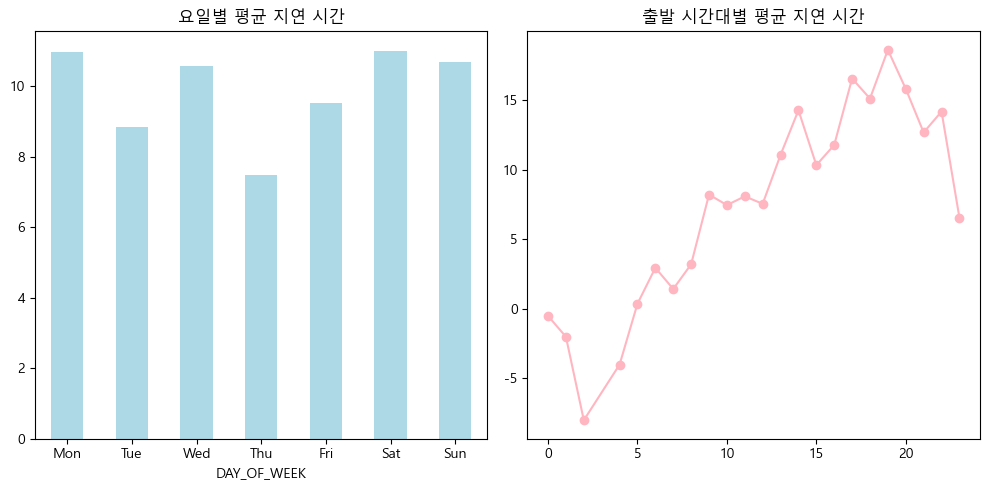

In [9]:
# 시각화
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# 서브플롯 1 : 요일별 평균 지연 시간
# 요일 : 숫자 -> 문자 표시
day_labels=['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

plt.subplot(1,2,1)
delay_by_day.plot(kind='bar', color='lightblue')
plt.title('요일별 평균 지연 시간')
plt.xticks(range(7), day_labels, rotation=0)

# 서브플롯 2 : 출발 시간대별 평균 지연 시간
# 요일별 평균 지연 시간
plt.subplot(1,2,2)
delay_by_hour.plot(marker='o', color='lightpink')
plt.title('출발 시간대별 평균 지연 시간')
plt.xlabel('')
plt.ylabel('')

plt.tight_layout()
plt.show()

### 타겟 컬럼 생성
DEPARTURE_DELAY컬럼에서 15분을 기준으로 DELAYED 타겟 컬럼 생성
- 15분 이상 : 지연 (1)
- 15분 이하 : 정상 (0)

In [10]:
# 지연 여부 컬럼 생성 int로 변환
flight_df = flight.copy()
flight_df['DELAYED'] = (flight_df['DEPARTURE_DELAY'] >= 15).astype(int)
flight_df

,MONTH,DAY_OF_WEEK,AIRLINE,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,DISTANCE,DEPARTURE_DELAY,HOUR,DELAYED
1508570,4,2,EV,FWA,DTW,1340,128,-5.0,13,0
363270,1,6,AS,LAS,SEA,1910,867,-12.0,19,0
3003945,7,3,WN,OAK,SEA,630,672,-4.0,6,0
2291425,5,2,WN,STL,DAL,810,546,153.0,8,1
2973084,7,1,UA,IAH,HNL,1000,3904,8.0,10,0
...,...,...,...,...,...,...,...,...,...,...
2501394,6,7,EV,ATL,SHV,2305,551,4.0,23,0
1212176,3,5,DL,ATL,BOS,902,946,9.0,9,0
3320074,7,7,WN,HOU,HRL,1845,277,-2.0,18,0
1991163,5,4,B6,SYR,JFK,1116,209,-3.0,11,0


모델이 정답을 미리 보지 않도록 DEPARTURE_DELAY 컬럼 제거

In [11]:
# DEPARTURE_DELAY 컬럼 제거
flight_df = flight_df.drop(columns=['DEPARTURE_DELAY'])
flight_df

,MONTH,DAY_OF_WEEK,AIRLINE,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,DISTANCE,HOUR,DELAYED
1508570,4,2,EV,FWA,DTW,1340,128,13,0
363270,1,6,AS,LAS,SEA,1910,867,19,0
3003945,7,3,WN,OAK,SEA,630,672,6,0
2291425,5,2,WN,STL,DAL,810,546,8,1
2973084,7,1,UA,IAH,HNL,1000,3904,10,0
...,...,...,...,...,...,...,...,...,...
2501394,6,7,EV,ATL,SHV,2305,551,23,0
1212176,3,5,DL,ATL,BOS,902,946,9,0
3320074,7,7,WN,HOU,HRL,1845,277,18,0
1991163,5,4,B6,SYR,JFK,1116,209,11,0


학습 데이터와 테스트 데이터 분리
- AIRLINE은 문자이기때문에 인코딩 필요
    - X : 사용할 features 선택 -> AIRLINE 인코딩 후 덮어쓰기

In [12]:
# 사용할 features 선택
features = ['MONTH', 'DAY_OF_WEEK', 'HOUR', 'DISTANCE', 'AIRLINE']

# X, y 분리
X_flight_df = flight_df[features]
y_flight_df = flight_df['DELAYED']

# AIRLINE 원핫 인코딩
X_flight_df = pd.get_dummies(X_flight_df, columns=['AIRLINE'])

In [13]:
# 학습 데이터와 테스트 데이터 분리
X_train, X_test, y_train, y_test = train_test_split(
    X_flight_df,
    y_flight_df,
    test_size=0.2,
    random_state=42,
    stratify=y_flight_df    # 지연 / 비지연 비율 유지
)

In [ ]:
print(f"훈련 데이터(X_train) 개수: {X_train.shape[0]}행, {X_train.shape[1]}열")
print(f"테스트 데이터(X_test) 개수: {X_test.shape[0]}행, {X_test.shape[1]}열")

In [14]:
model = RandomForestClassifier(
    n_estimators=100,   # 트리갯수
    random_state=42
)

# 학습
model.fit(X_train, y_train)

# 예측
pred = model.predict(X_test)
acc = accuracy_score(y_test, pred)

print(f"정확도 : {acc:.2f}")

정확도 : 0.79


모델 성능 향상 시키기...

In [16]:
param_grid = {
    'n_estimators': [100,200],
    'max_depth': [None, 10,20],
    'min_samples_split': [2,5]
}

rf = RandomForestClassifier(random_state=42)

grid_search = GridSearchCV(
    rf,
    param_grid,
    cv=3,
    scoring = 'f1',
    n_jobs = -1,
    verbose = 2
)

grid_search.fit(X_train, y_train)


print(f"최적 파라미터 {grid_search.best_params_}")
print("CV 최고 F1:", grid_search.best_score_)



Fitting 3 folds for each of 12 candidates, totalling 36 fits
최적 파라미터 {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
CV 최고 F1: 0.11431836494078962


In [17]:
pred = grid_search.predict(X_test)

print(pred)

[0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 1 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 1 0 0 1 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0
 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 